# Law of Large Numbers

The law of large numbers (LLN) states that the average of the results of a large number of independent random samples converges to the expected value. The two main versions of the LLN are called the weak and the strong laws. Formally, the weak law of large numbers (WLLN) is defined as follows:

Let $X_1, X_2, X_3, ..., X_n$ be independent and identically distributed random variables with a finite expected value $E[X_i]=\mu<\infty$. 
Also, let $\bar{X}=\frac{1}{n}\sum_{i=1}^n X_i$.

Then for any $\epsilon>0$,
$$\lim_{n\rightarrow\infty}P(|\bar{X}-\mu|\geq\epsilon)=0$$

The law says that as $n\rightarrow\infty$, the probability that the difference between $\bar{X}$ and ${\mu}$ is greater than or equal to any $\epsilon$ vanishes. Or equivalently, the probability that $\bar{X}$ is close to ${\mu}$ is very large for large $n$.

In [19]:
import numpy.random as rand
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def plotDistribution(distribution, *params):

    expectation = params[0]

    if distribution == "normal":
        xs = np.linspace(params[0]-5, params[0]+5, 500)
        ys = 1/np.sqrt(2*np.pi*params[1]**2)*np.exp(-((xs-params[0])**2)/(2*params[1]**2))

    if distribution == "exponential":
        xs = np.linspace(0, 10, 500)
        lam = 1/params[0]
        ys = lam*np.exp(-lam*xs)
   
    sns.scatterplot(x=xs, y=ys, size=1, legend=False)
    plt.plot([expectation,expectation], [0,1], c="r", label="Expectation")
    plt.legend()
    plt.xlabel(r"$x$")
    plt.ylabel(r"$p(x)$")
    plt.ylim(0, max(ys)+0.2*max(ys))

def plotAbsMeanMinusExpect(distribution, samples, expectedValue, *params):

    vals = []

    for i in range(1, samples+1):
        if distribution == "normal":
            sample = rand.normal(params[0], params[1], i)
        
        if distribution == "exponential":
            sample = rand.exponential(params[0], i)
            
        sampleMean = np.mean(sample)
        vals.append(np.absolute(sampleMean - expectedValue))
    
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"$|\bar{X}-\mu|$")
    ax.scatter(range(1, samples+1), vals, marker=1)

We begin by looking at the pdf of the normal distribution with $\mu=2$ and $\sigma=1$. This distribution also has the expectation $E[X]=2$.

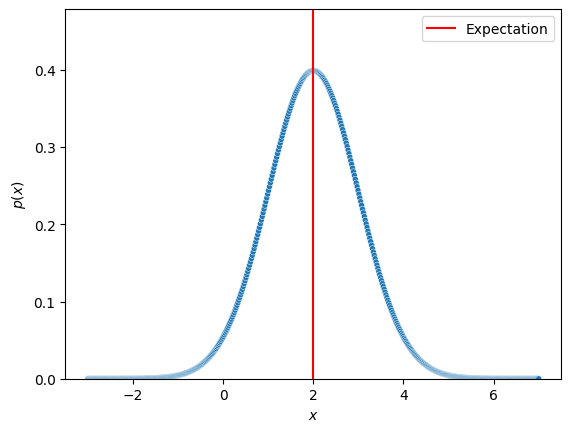

In [21]:
plotDistribution("normal", 2, 1)

Below we plot $|\bar{X}-\mu|$ against the number of samples taken from the normal distribution. We can see that the difference between $\bar{X}$ and $\mu$ decreases as $n$ increases, since the reliability of the sample mean as an estimate of the true mean improves as more samples are taken.

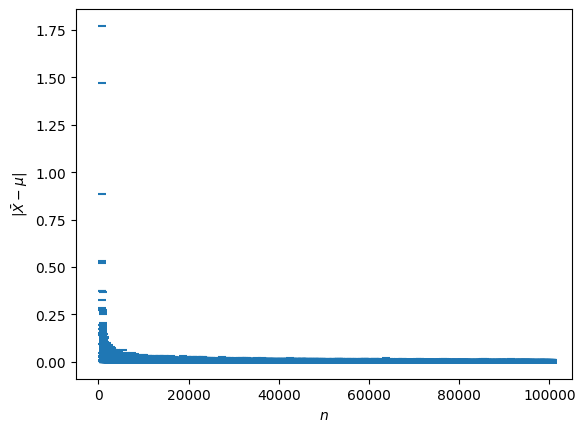

In [22]:
plotAbsMeanMinusExpect("normal", 100000, 2, 2, 1)

Next we will take a look at the exponential distribution with $\lambda=1/5$ and $E[X]=5$.

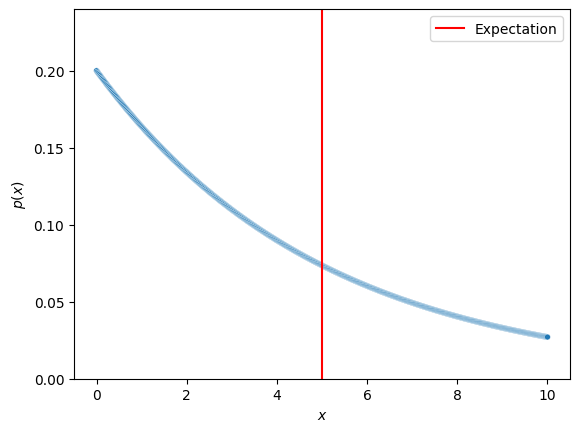

In [23]:
plotDistribution("exponential", 5)

Again, when plotting $|\bar{X}-\mu|$ against $n$, we see that the difference between $\bar{X}$ and $\mu$ decreases as $n$ increases.

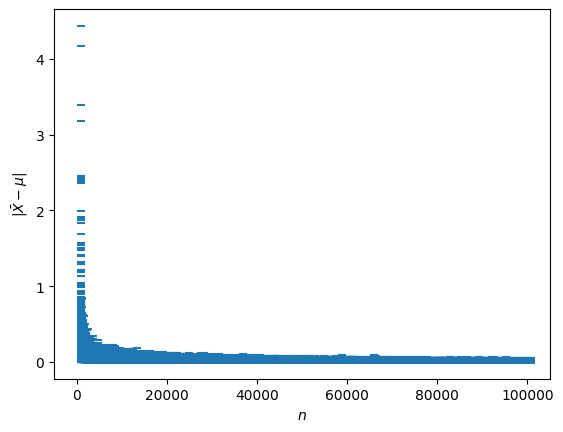

In [24]:
plotAbsMeanMinusExpect("exponential", 100000, 5, 5)